## Supplementary Material:

This notebook is used to predict interfacial properties (i.e., interfacial concentration profiles and surface tension) for hexane + cyclopentyl methyl ether + propan-1-ol ternary mixture at 298.15 k and 101.30 kPa using the SGT coupled to SAFT-VR Mie EoS proposed by Lafitte et al.  

This notebook uses an external Excel file (experimental_data.xlsx) which contains the experimental data and the SGTPy suite, which is free download at https://pypi.python.org/pypi/sgtpy/

For further details, the reader is redirected to “Thermophysical characterization of the synthetic oxygenate fuel mixture formed by hexane + cyclopentyl methyl ether + propan-1-ol” by Isaías Huenuvil-Pacheco, Marcela Cartes and Andrés Mejía submitted to the ChemSusChem Journal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import bubblePy
from sgtpy.sgt import sgt_mix, msgt_mix

In [2]:
# Creating pure components
hexane = component('hexane', ms = 1.96720036, sigma = 4.54762477, eps = 377.60127994, 
                   lambda_r = 18.41193194, lambda_a = 6.0, cii = 3.58101725e-19 )

cpme = component('cpme', ms = 2.34183523, sigma = 4.12538522, eps = 344.80694006, lambda_r = 14.1775199,
                 lambda_a = 6.0, sites = [0,0,1], cii = 3.57175418e-19)

propanol = component('propanol', ms = 2.2513, sigma = 3.6008 , eps = 253.45,
                    lambda_r = 11.960, lambda_a = 6., eAB = 2794.88, rcAB = 0.3481, sites = [1,0,1], cii = [8.67969723e-20])

# Creating a mixture: hexane (1) + cpme (2) + propanol (3)
mix = hexane + cpme + propanol

# setting up kij interaction parameters 

k12, l12 = np.array([ 0.00295, 0]) # hexane (1) cpme (2) 

k13, l13 = np.array([ 4.227e-03, 0]) # hexane (1) propanol (3)

k23, l23 = np.array([ 0.0123,  0]) # cpme (2) propanol (3) with rcAB

#rc induced association
rc12 = 0
rc13 = 1.312e+00
rc23 = 2.206   


# setting up interaction corrections
Kij = np.array([[0., k12, k13], [k12, 0., k23], [k13, k23, 0.]])
Lij = np.array([[0., l12, l13], [l12, 0., l23], [l13, l23, 0.]])
mix.kij_saft(Kij)
mix.lij_saft(Lij)

eos = saftvrmie(mix) 

eos.eABij[2,0] = propanol.eAB / 2
eos.eABij[0,2] = propanol.eAB / 2
eos.rcij[2,0] = rc13 * 1e-10
eos.rcij[0,2] = rc13 * 1e-10

eos.eABij[2,1] = propanol.eAB / 2
eos.eABij[1,2] = propanol.eAB / 2
eos.rcij[2,1] = rc23 * 1e-10
eos.rcij[1,2] = rc23 * 1e-10


# beta para SGT
b12 = 0                     # hexane (1) cpme (2)
b13 = 0.09275622156258277   # hexane (1) propanol (3)
b23 = 0.058291634511911765  # cpme (2) propanol (3)  
eos.set_betaijsgt(i=0, j=1, beta0=b12) 
eos.set_betaijsgt(i=0, j=2, beta0=b13) 
eos.set_betaijsgt(i=1, j=2, beta0=b23) 

In [14]:
df = pd.read_excel('experimental_data.xlsx', 'IFT')

Texp = np.asarray(df.iloc[:, 0])  # K
# composición de fase líquida
xhexane = np.asarray(df.iloc[:, 1])
xcpme = np.asarray(df.iloc[:, 2])
xpropanol = np.asarray(df.iloc[:, 3])
Xexp = np.array([xhexane, xcpme, xpropanol])
# IFT experimental
ift_exp = np.asarray(df.iloc[:, 4]) # mN/m
df.head(n=5)

,T/K,xHexane,xCPME,xPropanol,IFT /mN/m
0,298.15,0.085576,0.805696,0.108728,23.44
1,298.15,0.081771,0.709617,0.208612,23.46
2,298.15,0.081140,0.610555,0.308305,23.39
3,298.15,0.085494,0.513119,0.401387,22.87
4,298.15,0.088555,0.412684,0.498761,22.92


In [4]:
n = len(Texp)
# creating arrays to store results
P = np.zeros(n)
Y = np.zeros([3, n])
vl = np.zeros(n)
vv = np.zeros(n)


for i in range(n):
    # initial guesses to start phase equilibria calculation
    Y0 = 1.*Xexp[:, i]
    P0 = 1e4
    # computing phase equilibria
    sol = bubblePy(Y0, P0, Xexp[:, i], Texp[i], eos, full_output=True)
    # storing vapor composition, equilibria pressure and volumes
    Y[:, i], P[i] = sol.Y, sol.P
    vl[i], vv[i] = sol.v1, sol.v2
    # print(i, sol.Y, sol.P, sol.error, sol.iter) # uncomment to output computation information

# computing density vectors
rhol = Xexp/vl
rhov = Y/vv



In [ ]:
# creating array to store interfacial tension results
ift_sgt = np.zeros(n)
# creating list to store all the solution information
solsgt = []
for i in range(n):
    sol = msgt_mix(rhov[:, i], rhol[:, i], Texp[i], P[i], eos, z=20., ds=25, full_output=True) # these calculations can be slow
    solsgt.append(sol)
    ift_sgt[i] = sol.tension
    #print(i, ift_sgt[i], ift_exp[i])  #uncomment to show iterations

In [6]:
# computing error from experimental measurements
print('IFT AAD: ', 100 * np.mean(np.abs(ift_sgt/ift_exp - 1)))

IFT AAD:  1.5221838450286307


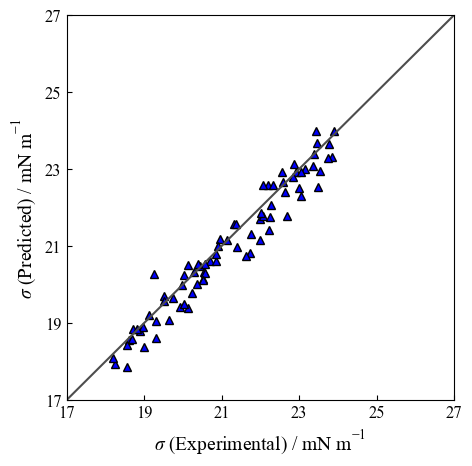

In [7]:
plt.rc('text', usetex=False )

plt.rc('font', family="Times New Roman", weight='normal', size=12)
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
fontsize = 14

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)

ax.plot(ift_exp, ift_sgt, 'o', color = 'black',mfc='blue')
ax.set_ylabel(r'$\sigma$ (Predicted) / mN m$^{-1}$', fontsize=fontsize)
ax.set_xlabel(r'$\sigma$ (Experimental) / mN m$^{-1}$', fontsize=fontsize)

lim = [17, 25]
ax.plot(lim, lim, c = '0.3')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xticks(np.arange(17, 28, 2))
ax.set_yticks(np.arange(17, 28, 2))

ax.tick_params(direction='in')

In [8]:
# setting equilibrium temperature and liquid composition
T_profile = 298.15  # K
x_profile = np.array([0.6,0.3,0.1]) 


P0 = 1e4 # Pa, equilibrium pressure initial gues

y0 = np.array([0.6, 0.3, 0.1]) # vapor compisition initial guess

solvle = bubblePy(y0, P0, x_profile, T_profile, eos, full_output=True)
print('Equilibrium pressure: ', solvle.P, ' Pa')
print('Equilibrium vapor composition: ', solvle.Y)
print('Equilibrium liquid volume: ', solvle.v1, ' m3/mol')
print('Equilibrium vapor volume: ', solvle.v2, ' m3/mol')


# Reading solution object
y_profile = solvle.Y
P_profile = solvle.P
vl_profile = solvle.v1
vv_profile = solvle.v2
# computing density vectors
rhol_profile = x_profile/vl_profile
rhov_profile = y_profile/vv_profile

# computing density profile with MSGT at 20 Amstrongs and time step=
sgt_profile = msgt_mix(rhov_profile, rhol20_profile, T_profile, P_profile, eos, z=20., ds=25, full_output=True)
print('Computed IFT: ', sgt_profile.tension, ' mN/m')


Equilibrium pressure:  16653.989949617648  Pa
Equilibrium vapor composition:  [0.83053855 0.09257553 0.07688592]
Equilibrium liquid volume:  0.00012141398469370103  m3/mol
Equilibrium vapor volume:  0.14768042608642223  m3/mol
Computed IFT:  19.64616903020496  mN/m


Text(0, 0.5, '$\\rho$ / kmol m$^{-3}$')

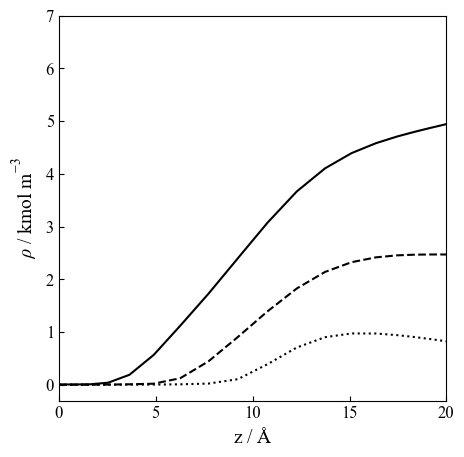

In [9]:
# reading solution
rho = sgt_profile.rho / 1000. # kmol/m3
z = sgt_profile.z # Amstrong

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)

ax.plot(z, rho[0], color='k', label='n-Hexane')
ax.plot(z, rho[1], '--', color='k', label='CPME')
ax.plot(z, rho[2], ':', color='k', label='Propan-1-ol')

ax.set_xlim([z[0], z[-1]])
ax.set_ylim([-0.3,7])
ax.tick_params(direction='in')

ax.set_xlabel(r'z / $\rm \AA$', fontsize=fontsize)
ax.set_ylabel(r'$\rho$ / kmol m$^{-3}$', fontsize=fontsize)
